# IN718 Sample 0: Basic vs Symmetry-Aware vs Boundary-Aware SLERP

Pipeline uses:
- `slerp_final.py`
- `segment_grains.py`

Methods tested on Test sample `0`:
1. Basic SLERP (no symmetry)
2. Symmetry-aware SLERP (`SymBilinearSlerpUpsample`)
3. Boundary-aware symmetry SLERP (label/SDF guided)


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from orix.quaternion import symmetry as SYM

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "training").exists():
    REPO_ROOT = REPO_ROOT.parent

NB_DIR = REPO_ROOT / "notebooks"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

from training.quaternion_dataset import QuaternionDataset
from visualization.ipf_render import render_ipf_image, render_ipf_rgb

from slerp_final import (
    SymBilinearSlerpUpsample,
    bilinear_slerp_sym,
    make_fcc_symmetry_4x4,
    qnorm,
    slerp,
    symmetrize_pair,
)
from segment_grains import (
    build_sdf,
    build_smooth_hr_labels,
    cleanup_small_grains_cuda,
    segment_grains_graph,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [2]:
dataset_dir = Path("/data/warren/materials/EBSD/IN718_FZ_2D_SR_x4")
sample_idx = 0
scale = 4
out_dir = REPO_ROOT / "outputs" / "in718_sample0_slerp_final_segment_grains"
out_dir.mkdir(parents=True, exist_ok=True)

ds = QuaternionDataset(dataset_root=str(dataset_dir), split="Test")
q_lr = ds[sample_idx][0].unsqueeze(0).to(device=device, dtype=torch.float32)
q_hr_gt = ds[sample_idx][1].unsqueeze(0).to(device=device, dtype=torch.float32)
q_lr = qnorm(q_lr)
q_hr_gt = qnorm(q_hr_gt)

sym_np_path = REPO_ROOT / "symmetry_groups" / "O_group.npy"
if sym_np_path.exists():
    sym_ops = torch.tensor(np.load(sym_np_path), dtype=q_lr.dtype, device=device)
else:
    sym_ops = make_fcc_symmetry_4x4(device=device, dtype=q_lr.dtype)

sym_class = SYM.O
print("q_lr shape:", tuple(q_lr.shape))
print("q_hr_gt shape:", tuple(q_hr_gt.shape))
print("sym_ops shape:", tuple(sym_ops.shape))
print("out_dir:", out_dir)


q_lr shape: (1, 4, 32, 32)
q_hr_gt shape: (1, 4, 128, 128)
sym_ops shape: (24, 4, 4)
out_dir: /home/warren/projects/Reynolds-QSR/outputs/in718_sample0_slerp_final_segment_grains


In [3]:
class BasicBilinearSlerpUpsample(nn.Module):
    """Basic bilinear SLERP upsampler without symmetry handling."""

    def __init__(self, scale_factor: int):
        super().__init__()
        self.scale = int(scale_factor)

    @torch.no_grad()
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        assert C == 4
        s = self.scale
        x = qnorm(x)

        H_out, W_out = H * s, W * s
        device, dtype = x.device, x.dtype

        iy = torch.arange(H_out, device=device, dtype=dtype)
        ix = torch.arange(W_out, device=device, dtype=dtype)
        y = (iy + 0.5) / s - 0.5
        xcoord = (ix + 0.5) / s - 0.5

        y0 = torch.floor(y).clamp(0, H - 1).long()
        x0 = torch.floor(xcoord).clamp(0, W - 1).long()
        y1 = (y0 + 1).clamp(0, H - 1)
        x1 = (x0 + 1).clamp(0, W - 1)

        v = (y - y0.to(dtype)).clamp(0.0, 1.0)
        u = (xcoord - x0.to(dtype)).clamp(0.0, 1.0)
        v_grid, u_grid = torch.meshgrid(v, u, indexing="ij")

        y0g = y0.view(H_out, 1).expand(H_out, W_out)
        y1g = y1.view(H_out, 1).expand(H_out, W_out)
        x0g = x0.view(1, W_out).expand(H_out, W_out)
        x1g = x1.view(1, W_out).expand(H_out, W_out)

        q00 = x[:, :, y0g, x0g]
        q01 = x[:, :, y0g, x1g]
        q10 = x[:, :, y1g, x0g]
        q11 = x[:, :, y1g, x1g]

        def flat(q: torch.Tensor) -> torch.Tensor:
            return q.permute(0, 2, 3, 1).reshape(-1, 4)

        q00_f = flat(q00)
        q01_f = flat(q01)
        q10_f = flat(q10)
        q11_f = flat(q11)

        u_full = u_grid.unsqueeze(0).expand(B, -1, -1).reshape(-1)
        v_full = v_grid.unsqueeze(0).expand(B, -1, -1).reshape(-1)

        q0u = slerp(q00_f, q01_f, u_full)
        q1u = slerp(q10_f, q11_f, u_full)
        q_uv = slerp(q0u, q1u, v_full)

        out = q_uv.view(B, H_out, W_out, 4).permute(0, 3, 1, 2).contiguous()
        return qnorm(out)


def plot_lr_hr_labels_panels_with_sdf(
    labels_lr,
    labels_hr,
    sdf_hr,
    out_png,
    lr_zoom=(slice(20, 35), slice(None)),
    hr_zoom1=(slice(65, 125), slice(None)),
    hr_zoom2=(slice(110, 125), slice(70, 85)),
):
    lr_np = labels_lr.detach().cpu().numpy()
    hr_np = labels_hr.detach().cpu().numpy()
    sdf_np = sdf_hr.detach().cpu().numpy()

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    ax = axes.flatten()

    ax[0].imshow(lr_np, cmap="tab20")
    ax[0].set_title("LR Labels")
    ax[0].axis("off")

    ax[1].imshow(lr_np[lr_zoom], cmap="tab20")
    ax[1].set_title(f"LR Zoom {lr_zoom}")
    ax[1].axis("off")

    ax[2].imshow(hr_np, cmap="tab20")
    ax[2].set_title("HR Smooth Labels")
    ax[2].axis("off")

    ax[3].imshow(hr_np[hr_zoom1], cmap="tab20")
    ax[3].set_title(f"HR Zoom 1 {hr_zoom1}")
    ax[3].axis("off")

    ax[4].imshow(hr_np[hr_zoom2], cmap="tab20")
    ax[4].set_title(f"HR Zoom 2 {hr_zoom2}")
    ax[4].axis("off")

    im = ax[5].imshow(sdf_np, cmap="viridis")
    ax[5].set_title("HR SDF (Smoothed Boundary Field)")
    ax[5].axis("off")
    fig.colorbar(im, ax=ax[5], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()
    print(f"Saved label/SDF panel -> {out_png}")


@torch.no_grad()
def analyze_boundary_cases(
    labels_lr: torch.Tensor,
    labels_hr: torch.Tensor,
    scale: int,
    out_png: str | None = None,
):
    device = labels_lr.device
    scale = int(scale)

    H_lr, W_lr = labels_lr.shape
    H_hr, W_hr = labels_hr.shape
    assert H_hr == H_lr * scale and W_hr == W_lr * scale

    yy_hr = torch.arange(H_hr, device=device, dtype=torch.float32)
    xx_hr = torch.arange(W_hr, device=device, dtype=torch.float32)
    y_hr, x_hr = torch.meshgrid(yy_hr, xx_hr, indexing="ij")

    y_lr_f = (y_hr + 0.5) / scale - 0.5
    x_lr_f = (x_hr + 0.5) / scale - 0.5

    y0 = torch.floor(y_lr_f).long().clamp(0, H_lr - 1)
    x0 = torch.floor(x_lr_f).long().clamp(0, W_lr - 1)
    y1 = (y0 + 1).clamp(0, H_lr - 1)
    x1 = (x0 + 1).clamp(0, W_lr - 1)

    ty = (y_lr_f - y0.float()).clamp(0.0, 1.0)
    tx = (x_lr_f - x0.float()).clamp(0.0, 1.0)

    w00 = (1.0 - tx) * (1.0 - ty)
    w01 = tx * (1.0 - ty)
    w10 = (1.0 - tx) * ty
    w11 = tx * ty

    g00 = labels_lr[y0, x0]
    g01 = labels_lr[y0, x1]
    g10 = labels_lr[y1, x0]
    g11 = labels_lr[y1, x1]

    g_neighbors = torch.stack((g00, g01, g10, g11), dim=-1)
    w_neighbors = torch.stack((w00, w01, w10, w11), dim=-1)
    same_mask = g_neighbors == labels_hr.unsqueeze(-1)

    N = H_hr * W_hr
    same_mask_flat = same_mask.reshape(N, 4)
    w_flat = w_neighbors.reshape(N, 4)

    num_valid = same_mask_flat.sum(dim=1)
    case_map_flat = torch.zeros(N, dtype=torch.uint8, device=device)
    case_map_flat[num_valid == 4] = 3
    case_map_flat[(num_valid >= 2) & (num_valid < 4)] = 2
    case_map_flat[num_valid == 1] = 1
    case_map = case_map_flat.view(H_hr, W_hr)

    if out_png is not None:
        case_np = case_map.detach().cpu().numpy()
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        im = ax.imshow(case_np, cmap="tab10", vmin=0, vmax=3)
        ax.set_title("Boundary Case Map: 0 none, 1 single, 2 multi, 3 interior")
        ax.axis("off")
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_ticks([0, 1, 2, 3])
        plt.tight_layout()
        plt.savefig(out_png, dpi=200)
        plt.close()
        print(f"Saved boundary case map -> {out_png}")

    return same_mask_flat, w_flat, case_map


@torch.no_grad()
def boundary_aware_sym_slerp_upsample(
    q_lr: torch.Tensor,
    labels_lr: torch.Tensor,
    labels_hr: torch.Tensor,
    sym_ops: torch.Tensor,
    scale: int,
    same_mask_flat: torch.Tensor,
    w_flat: torch.Tensor,
    case_map: torch.Tensor,
) -> torch.Tensor:
    device = q_lr.device
    dtype = q_lr.dtype
    scale = int(scale)

    B, C, H_lr, W_lr = q_lr.shape
    assert B == 1 and C == 4
    H_hr, W_hr = labels_hr.shape
    assert H_hr == H_lr * scale and W_hr == W_lr * scale

    yy_hr = torch.arange(H_hr, device=device, dtype=torch.float32)
    xx_hr = torch.arange(W_hr, device=device, dtype=torch.float32)
    y_hr, x_hr = torch.meshgrid(yy_hr, xx_hr, indexing="ij")

    y_lr_f = (y_hr + 0.5) / scale - 0.5
    x_lr_f = (x_hr + 0.5) / scale - 0.5

    y0 = torch.floor(y_lr_f).long().clamp(0, H_lr - 1)
    x0 = torch.floor(x_lr_f).long().clamp(0, W_lr - 1)
    y1 = (y0 + 1).clamp(0, H_lr - 1)
    x1 = (x0 + 1).clamp(0, W_lr - 1)

    ty = (y_lr_f - y0.float()).clamp(0.0, 1.0)
    tx = (x_lr_f - x0.float()).clamp(0.0, 1.0)
    u_flat = tx.reshape(-1)
    v_flat = ty.reshape(-1)

    q_lr_hw = q_lr.squeeze(0).permute(1, 2, 0).contiguous()
    q00 = q_lr_hw[y0, x0]
    q01 = q_lr_hw[y0, x1]
    q10 = q_lr_hw[y1, x0]
    q11 = q_lr_hw[y1, x1]

    N = H_hr * W_hr
    q00_flat = q00.reshape(N, 4)
    q01_flat = q01.reshape(N, 4)
    q10_flat = q10.reshape(N, 4)
    q11_flat = q11.reshape(N, 4)

    q_neighbors_flat = torch.stack((q00_flat, q01_flat, q10_flat, q11_flat), dim=1)
    case_flat = case_map.reshape(-1)
    gid_hr_flat = labels_hr.reshape(-1)
    y_lr_f_flat = y_lr_f.reshape(-1)
    x_lr_f_flat = x_lr_f.reshape(-1)

    q_out_flat = torch.zeros((N, 4), dtype=dtype, device=device)

    mask3 = case_flat == 3
    idx3 = torch.nonzero(mask3, as_tuple=False).squeeze(1)
    if idx3.numel() > 0:
        q_uv_3 = bilinear_slerp_sym(
            q00_flat[idx3],
            q01_flat[idx3],
            q10_flat[idx3],
            q11_flat[idx3],
            u_flat[idx3],
            v_flat[idx3],
            sym_ops,
        )
        q_out_flat[idx3] = q_uv_3

    mask1 = case_flat == 1
    idx1 = torch.nonzero(mask1, as_tuple=False).squeeze(1)
    if idx1.numel() > 0:
        same1 = same_mask_flat[idx1]
        pos1 = same1.long().argmax(dim=1)
        q_nb1 = q_neighbors_flat[idx1]
        b_idx = torch.arange(idx1.numel(), device=device)
        q_out_flat[idx1] = q_nb1[b_idx, pos1]

    mask2 = case_flat == 2
    idx2 = torch.nonzero(mask2, as_tuple=False).squeeze(1)
    if idx2.numel() > 0:
        q_nb2 = q_neighbors_flat[idx2]
        w2 = w_flat[idx2]
        same2 = same_mask_flat[idx2]
        N2 = idx2.numel()

        for i in range(N2):
            q_corners = q_nb2[i]
            m = same2[i]
            w = w2[i].clone()

            valid_idx = torch.nonzero(m, as_tuple=False).squeeze(1)
            K = valid_idx.numel()
            if K == 0:
                continue

            qv = q_corners[valid_idx]
            wv = w[valid_idx]
            wv = wv / (wv.sum() + 1e-12)

            q_ref = qv[0:1]
            total_w = wv[0].clone()
            for k in range(1, K):
                wk = wv[k]
                alpha = wk / (total_w + wk + 1e-12)
                q_ref_aligned, q_next = symmetrize_pair(q_ref, qv[k : k + 1], sym_ops)
                q_ref = slerp(
                    q_ref_aligned,
                    q_next,
                    torch.tensor([alpha], device=device, dtype=dtype),
                )
                total_w = total_w + wk

            q_out_flat[idx2[i]] = q_ref[0]

    mask0 = case_flat == 0
    idx0 = torch.nonzero(mask0, as_tuple=False).squeeze(1)
    if idx0.numel() > 0:
        labels_lr_cpu = labels_lr.detach().cpu()
        q_lr_hw_cpu = q_lr_hw.detach().cpu()
        max_r = 3

        for j in idx0.tolist():
            gid = int(gid_hr_flat[j].item())
            y_est = int(round(float(y_lr_f_flat[j].item())))
            x_est = int(round(float(x_lr_f_flat[j].item())))

            best_q = None
            found = False
            for r in range(1, max_r + 1):
                for dy in range(-r, r + 1):
                    for dx in range(-r, r + 1):
                        yy = min(max(y_est + dy, 0), H_lr - 1)
                        xx = min(max(x_est + dx, 0), W_lr - 1)
                        if int(labels_lr_cpu[yy, xx].item()) == gid:
                            best_q = q_lr_hw_cpu[yy, xx]
                            found = True
                            break
                    if found:
                        break
                if found:
                    break

            if best_q is None:
                yy = min(max(y_est, 0), H_lr - 1)
                xx = min(max(x_est, 0), W_lr - 1)
                best_q = q_lr_hw_cpu[yy, xx]

            q_out_flat[j] = qnorm(best_q.to(device=device, dtype=dtype).unsqueeze(0))[0]

    q_hr = q_out_flat.view(H_hr, W_hr, 4).permute(2, 0, 1).unsqueeze(0).contiguous()
    return qnorm(q_hr)


In [4]:
# Segment grains from sample 0 and build smooth HR labels/SDF
labels_np, n_grains = segment_grains_graph(q_lr.cpu(), sym_ops.cpu(), thr_deg=3.0)
labels_lr = torch.from_numpy(labels_np).long().to(device)
labels_lr = cleanup_small_grains_cuda(
    labels_lr,
    q_lr,
    sym_ops,
    min_pixels=3,
    max_iter=1,
)

labels_hr = build_smooth_hr_labels(labels_lr, scale=scale, sdf_shift=0.7)
sdf_hr = build_sdf(labels_lr, scale=scale)

same_mask_flat, w_flat, case_map = analyze_boundary_cases(
    labels_lr,
    labels_hr,
    scale=scale,
    out_png=str(out_dir / "boundary_case_map.png"),
)

plot_lr_hr_labels_panels_with_sdf(
    labels_lr,
    labels_hr,
    sdf_hr,
    out_png=str(out_dir / "lr_hr_sdf_overview.png"),
)

print("grains (initial graph):", n_grains)


Saved boundary case map -> /home/warren/projects/Reynolds-QSR/outputs/in718_sample0_slerp_final_segment_grains/boundary_case_map.png
Saved label/SDF panel -> /home/warren/projects/Reynolds-QSR/outputs/in718_sample0_slerp_final_segment_grains/lr_hr_sdf_overview.png
grains (initial graph): 9


In [5]:
# Run the three upsampling variants
basic_up = BasicBilinearSlerpUpsample(scale_factor=scale).to(device)
sym_up = SymBilinearSlerpUpsample(
    scale_factor=scale,
    seam_threshold_deg=5.0,
    device=str(device),
    dtype=q_lr.dtype,
).to(device)

with torch.inference_mode():
    q_hr_basic = basic_up(q_lr)
    q_hr_sym = sym_up(q_lr)

q_hr_boundary = boundary_aware_sym_slerp_upsample(
    q_lr=q_lr,
    labels_lr=labels_lr,
    labels_hr=labels_hr,
    sym_ops=sym_ops,
    scale=scale,
    same_mask_flat=same_mask_flat,
    w_flat=w_flat,
    case_map=case_map,
)

q_hr_basic = qnorm(q_hr_basic)
q_hr_sym = qnorm(q_hr_sym)
q_hr_boundary = qnorm(q_hr_boundary)

print("q_hr_basic:", tuple(q_hr_basic.shape))
print("q_hr_sym:", tuple(q_hr_sym.shape))
print("q_hr_boundary:", tuple(q_hr_boundary.shape))


[SymBilinearSlerpUpsample] seam crossings: 10428/32768 (31.824%)
q_hr_basic: (1, 4, 128, 128)
q_hr_sym: (1, 4, 128, 128)
q_hr_boundary: (1, 4, 128, 128)


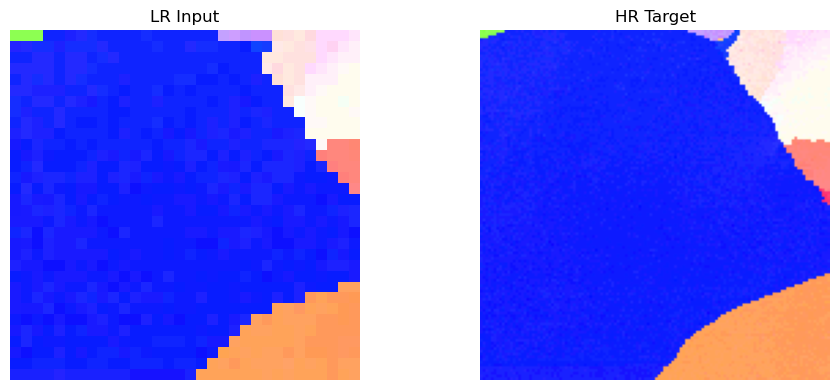

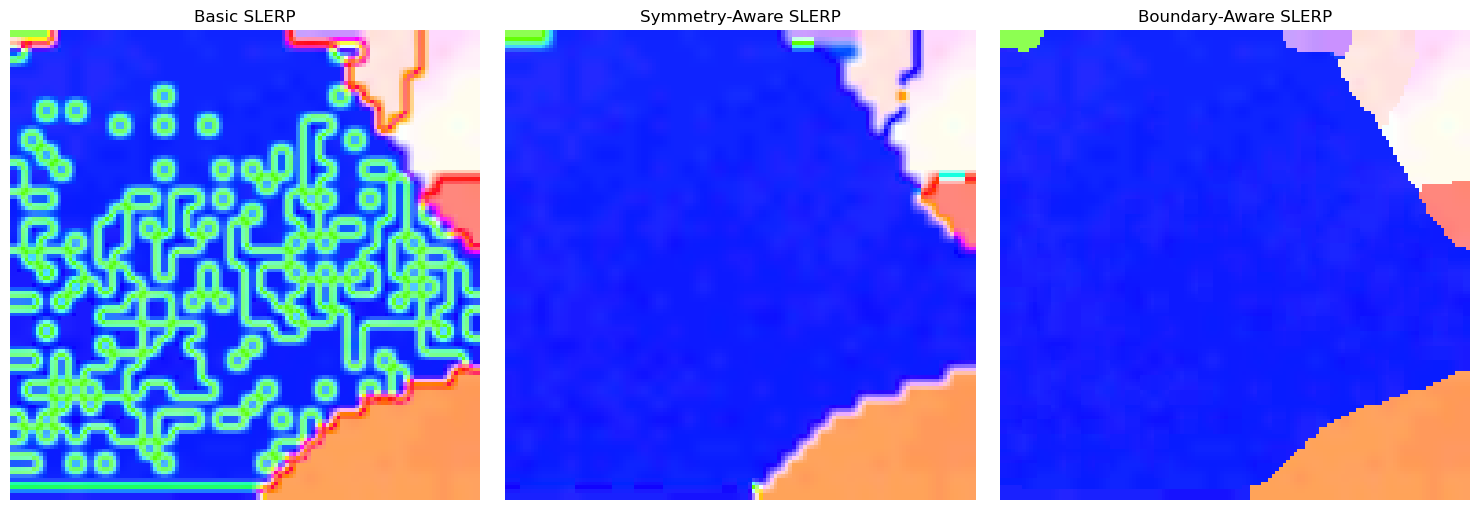

Saved outputs to: /home/warren/projects/Reynolds-QSR/outputs/in718_sample0_slerp_final_segment_grains


In [6]:
def to_hwc_np(q: torch.Tensor) -> np.ndarray:
    return q.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()

q_lr_np = to_hwc_np(q_lr)
q_hr_gt_np = to_hwc_np(q_hr_gt)
q_basic_np = to_hwc_np(q_hr_basic)
q_sym_np = to_hwc_np(q_hr_sym)
q_boundary_np = to_hwc_np(q_hr_boundary)

# Show LR and HR target first (before SR results)
rgb_lr = render_ipf_rgb(q_lr_np, sym_class, ref_dir="Z")
rgb_hr_gt = render_ipf_rgb(q_hr_gt_np, sym_class, ref_dir="Z")
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(rgb_lr); ax[0].set_title("LR Input") ; ax[0].axis("off")
ax[1].imshow(rgb_hr_gt); ax[1].set_title("HR Target") ; ax[1].axis("off")
plt.tight_layout()
plt.savefig(out_dir / "pre_slerp_lr_hr.png", dpi=200, bbox_inches="tight")
plt.show()

# Save standalone IPF images
render_ipf_image(q_lr_np, sym_class, out_png=str(out_dir / "ipf_lr.png"), ref_dir="Z", include_key=True, overwrite=True)
render_ipf_image(q_hr_gt_np, sym_class, out_png=str(out_dir / "ipf_hr_gt.png"), ref_dir="Z", include_key=True, overwrite=True)
render_ipf_image(q_basic_np, sym_class, out_png=str(out_dir / "ipf_hr_basic_slerp_x4.png"), ref_dir="Z", include_key=True, overwrite=True)
render_ipf_image(q_sym_np, sym_class, out_png=str(out_dir / "ipf_hr_symmetry_slerp_x4.png"), ref_dir="Z", include_key=True, overwrite=True)
render_ipf_image(q_boundary_np, sym_class, out_png=str(out_dir / "ipf_hr_boundary_slerp_x4.png"), ref_dir="Z", include_key=True, overwrite=True)

# Compare only SR maps side-by-side
rgb_basic = render_ipf_rgb(q_basic_np, sym_class, ref_dir="Z")
rgb_sym = render_ipf_rgb(q_sym_np, sym_class, ref_dir="Z")
rgb_boundary = render_ipf_rgb(q_boundary_np, sym_class, ref_dir="Z")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(rgb_basic); ax[0].set_title("Basic SLERP") ; ax[0].axis("off")
ax[1].imshow(rgb_sym); ax[1].set_title("Symmetry-Aware SLERP") ; ax[1].axis("off")
ax[2].imshow(rgb_boundary); ax[2].set_title("Boundary-Aware SLERP") ; ax[2].axis("off")
plt.tight_layout()
plt.savefig(out_dir / "comparison_panel.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved outputs to:", out_dir)
